In [1]:
import pathlib

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
l1g_path = pathlib.Path("/gws/ssde/j25b/eo_shared_data/vol1/satellite/isccp-ng/Data/l1g")

In [3]:
bt_11_00 = xr.open_mfdataset(
    sorted(list((l1g_path/"2024/08/22").glob("*__temp_11_00um__*.nc"))),
    combine="nested",
    concat_dim="time"
)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [4]:
bt_11_00

<xarray.Dataset> Size: 30GB
Dimensions:       (time: 48, layer: 3, latitude: 3600, longitude: 7200)
Coordinates:
  * latitude      (latitude) float64 29kB 89.98 89.93 89.88 ... -89.93 -89.98
  * longitude     (longitude) float64 58kB -180.0 -179.9 -179.9 ... 179.9 180.0
  * time          (time) datetime64[ns] 384B 2024-08-22 ... 2024-08-22T23:30:00
Dimensions without coordinates: layer
Data variables:
    crs           (time) int32 192B 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    temp_11_00um  (time, layer, latitude, longitude) float64 30GB dask.array<chunksize=(1, 1, 900, 900), meta=np.ndarray>

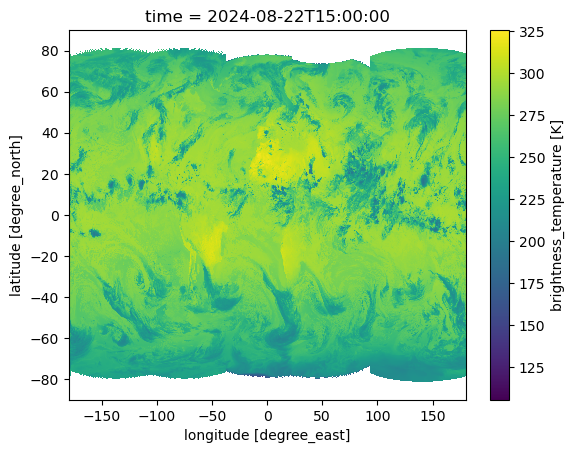

In [5]:
bt_11_00.temp_11_00um.sel(time="2024-08-22 15:00:00")[0].plot()

In [6]:
from pystac_client import Client

catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

import requests
import fsspec

CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    # print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

token = get_token()
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"], 
)

In [7]:
search = catalog.search(
    collections=EC_COLLECTION, 
    datetime="2024-08-22",
    # bbox=(-72, -12, 0, 32), 
    filter="(productType = 'CPR_FMR_2A')",# or (productType = 'CPR_CD__2A')",
    method = 'GET', # This is necessary 
)

In [8]:
len(list(search.items()))

124

In [9]:
df = pd.DataFrame(
    data={"stac":list(search.items())}
)
df["granule"] = [f.id[-6:] for f in df.stac]
df["product"] = [f.id[9:19] for f in df.stac]
df["date"] = [pd.to_datetime(f.id[20:35], format="%Y%m%dT%H%M%S") for f in df.stac]
df = df.sort_values(["date", "product"])

In [10]:
df

,stac,granule,product,date
18,<Item id=ECA_EXBA_CPR_FMR_2A_20240821T235038Z_...,01323C,CPR_FMR_2A,2024-08-21 23:50:38
79,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T000142Z_...,01323D,CPR_FMR_2A,2024-08-22 00:01:42
19,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T001329Z_...,01323E,CPR_FMR_2A,2024-08-22 00:13:29
21,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T002504Z_...,01323F,CPR_FMR_2A,2024-08-22 00:25:04
35,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T003652Z_...,01323G,CPR_FMR_2A,2024-08-22 00:36:52
...,...,...,...,...
41,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T231007Z_...,01338D,CPR_FMR_2A,2024-08-22 23:10:07
104,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T232153Z_...,01338E,CPR_FMR_2A,2024-08-22 23:21:53
23,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T233329Z_...,01338F,CPR_FMR_2A,2024-08-22 23:33:29
39,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T234517Z_...,01338G,CPR_FMR_2A,2024-08-22 23:45:17


In [11]:
from contextlib import contextmanager

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()


In [12]:
tracks = []

for idx, row in df.iterrows():
    with read_ec_file(row["stac"].assets.get('enclosure_h5').href) as ds:
        tracks.append(ds[["time", "latitude", "longitude"]].load())

In [13]:
len(tracks)

124

In [14]:
tracks[0]

<xarray.Dataset> Size: 20kB
Dimensions:    (along_track: 815)
Dimensions without coordinates: along_track
Data variables:
    time       (along_track) datetime64[ns] 7kB 2024-08-21T23:59:53.028439296...
    latitude   (along_track) float64 7kB 74.34 74.33 74.33 ... 67.4 67.39 67.38
    longitude  (along_track) float64 7kB -123.7 -123.8 -123.8 ... -133.0 -133.0

In [15]:
import zipfile, tempfile
def load_ec_archive(ec_file, variables=None):
    zf = zipfile.ZipFile(ec_file)

    with tempfile.TemporaryDirectory() as tempdir:
        zf.extractall(tempdir)
        f = list(pathlib.Path(tempdir).glob("*.h5"))[0]
        ec_ds = xr.open_datatree(f).ScienceData.to_dataset()
        if variables is not None:
            ec_ds = ec_ds[variables]
        ec_ds = ec_ds.load()
    
    return ec_ds

In [16]:
ec_path = pathlib.Path("/gws/ssde/j25b/eo_shared_data/vol1/satellite/earthcare/")

In [17]:
ec_files = sorted(list(ec_path.glob("L2a/CPR_FMR_2A/2024/08/22/*.ZIP")))

In [18]:
tracks = [
    load_ec_archive(f, variables=["time", "latitude", "longitude"]) 
    for f in ec_files
]

In [19]:
tracks[0]

<xarray.Dataset> Size: 120kB
Dimensions:    (along_track: 4990)
Dimensions without coordinates: along_track
Data variables:
    time       (along_track) datetime64[ns] 40kB 2024-08-22T00:48:02.60837081...
    latitude   (along_track) float64 40kB -67.61 -67.6 -67.6 ... -22.38 -22.38
    longitude  (along_track) float64 40kB 35.66 35.65 35.64 ... 18.36 18.35

In [20]:
import shapely
import geopandas as gpd

In [21]:
pd.DataFrame(
    data = dict(
        files=ec_files,
        start_time=[t.time.values[0] for t in tracks],
        end_time=[t.time.values[-1] for t in tracks]
    )
)

,files,start_time,end_time
0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520
1,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:59:51.492409728,2024-08-22 01:11:31.358272768
2,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 01:11:27.495381376,2024-08-22 01:23:18.509420416
3,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 02:20:36.135566208,2024-08-22 02:32:28.980402688
4,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 02:32:25.147035264,2024-08-22 02:44:04.978364416
5,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 02:44:01.155149952,2024-08-22 02:55:52.164337664
6,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 03:53:09.750702976,2024-08-22 04:05:02.634466944
7,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 04:04:58.773465856,2024-08-22 04:16:38.774631808
8,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 04:16:34.911777024,2024-08-22 04:28:25.789726720
9,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 05:37:32.427200256,2024-08-22 05:49:12.433551616


In [22]:
import antimeridian

cpr_gdf = gpd.GeoDataFrame(
    data=pd.DataFrame(
        data=dict(
            files=ec_files,
            start_time=pd.to_datetime([t.time.values[0] for t in tracks]), 
            end_time=pd.to_datetime([t.time.values[-1] for t in tracks]), 
        )
    ), 
    geometry=[
        antimeridian.fix_line_string(shapely.LineString(zip(t.longitude, t.latitude)), great_circle=True) for t in tracks
    ], 
    crs="EPSG:4326"
)

In [23]:
cpr_gdf

,files,start_time,end_time,geometry
0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6..."
1,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:59:51.492409728,2024-08-22 01:11:31.358272768,"LINESTRING (18.40549 -22.62461, 18.40363 -22.6..."
2,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 01:11:27.495381376,2024-08-22 01:23:18.509420416,"LINESTRING (9.71597 22.37434, 9.71414 22.3832,..."
3,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 02:20:36.135566208,2024-08-22 02:32:28.980402688,"LINESTRING (12.52881 -67.61863, 12.52093 -67.6..."
4,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 02:32:25.147035264,2024-08-22 02:44:04.978364416,"LINESTRING (-4.73354 -22.62459, -4.7354 -22.61..."
5,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 02:44:01.155149952,2024-08-22 02:55:52.164337664,"LINESTRING (-13.42396 22.37416, -13.42579 22.3..."
6,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 03:53:09.750702976,2024-08-22 04:05:02.634466944,"LINESTRING (-10.61117 -67.61965, -10.61905 -67..."
7,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 04:04:58.773465856,2024-08-22 04:16:38.774631808,"LINESTRING (-27.87391 -22.62604, -27.87577 -22..."
8,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 04:16:34.911777024,2024-08-22 04:28:25.789726720,"LINESTRING (-36.56533 22.38055, -36.56716 22.3..."
9,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 05:37:32.427200256,2024-08-22 05:49:12.433551616,"LINESTRING (-51.01624 -22.62499, -51.0181 -22...."


In [24]:
import earthaccess
auth = earthaccess.login()

In [25]:
imerg_results = earthaccess.search_data(
    short_name="GPM_3IMERGHH", 
    temporal=("2024-08-22", "2024-08-22"),
)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [26]:
len(imerg_results)

48

In [27]:
fileobjects = earthaccess.open(imerg_results)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/48 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/48 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/48 [00:00<?, ?it/s]

In [28]:
xr.open_dataset(fileobjects[0], group="Grid")

<xarray.Dataset> Size: 104MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2,
                                     lonv: 2, latv: 2)
Coordinates:
  * time                            (time) object 8B 2024-08-22 00:00:00
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float32 7kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv, lonv, latv
Data variables:
    time_bnds                       (time, nv) object 16B ...
    lon_bnds                        (lon, lonv) float32 29kB ...
    lat_bnds                        (lat, latv) float32 14kB ...
    precipitation                   (time, lon, lat) float32 26MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) float32 26MB ...
    precipitationQualityIndex       (time, lon, lat) float32 26MB ...
Attributes:
    GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeRe...

In [29]:
imerg_ds = xr.open_mfdataset(fileobjects, group="Grid", combine="nested", concat_dim="time")

In [30]:
imerg_ds

<xarray.Dataset> Size: 5GB
Dimensions:                         (time: 48, nv: 2, lon: 3600, lonv: 2,
                                     lat: 1800, latv: 2)
Coordinates:
  * time                            (time) object 384B 2024-08-22 00:00:00 .....
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float32 7kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv, lonv, latv
Data variables:
    time_bnds                       (time, nv) object 768B dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds                        (time, lon, lonv) float32 1MB dask.array<chunksize=(1, 3600, 2), meta=np.ndarray>
    lat_bnds                        (time, lat, latv) float32 691kB dask.array<chunksize=(1, 1800, 2), meta=np.ndarray>
    precipitation                   (time, lon, lat) float32 1GB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    randomError                     (time, lon, lat) float32 1GB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    probabilityLiquidPrecipitation  (time, lon, lat) float32 1GB dask.array<chunksize=(1, 291, 1800), meta=np.ndarray>
    precipitationQualityIndex       (time, lon, lat) float32 1GB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
Attributes:
    GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeRe...

In [31]:
results = earthaccess.search_data(
    short_name="SNDRJ1ML2RMS", 
    temporal=("2024-08-21 22:00:00", "2024-08-22"),
    # bounding_box=(-64, -6, -8, 24), 
    # day_night_flag="day", 
)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [32]:
len(results)

261

In [33]:
borders = [
    r["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]["GPolygons"][0]["Boundary"]["Points"]
    for r in results
]

In [34]:
borders[0]

[{'Longitude': 39.31, 'Latitude': 76.82},
 {'Longitude': 43.47, 'Latitude': 56.26},
 {'Longitude': 80.89, 'Latitude': 50.62},
 {'Longitude': 109.32, 'Latitude': 66.18},
 {'Longitude': 39.31, 'Latitude': 76.82}]

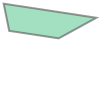

In [35]:
shapely.Polygon([list(b.values()) for b in borders[0][:-1]])

In [36]:
sounder_polys = [
    antimeridian.fix_polygon(shapely.Polygon([list(l.values()) for l in b[:-1]]))
    for b in borders
]

In [37]:
sounder_dates = [
    r["umm"]["TemporalExtent"]["RangeDateTime"]
    for r in results
]

In [38]:
sounder_dates

[{'BeginningDateTime': '2024-08-21T21:54:00.000Z',
  'EndingDateTime': '2024-08-21T22:00:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:00:00.000Z',
  'EndingDateTime': '2024-08-21T22:06:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:06:00.000Z',
  'EndingDateTime': '2024-08-21T22:12:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:12:00.000Z',
  'EndingDateTime': '2024-08-21T22:18:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:18:00.000Z',
  'EndingDateTime': '2024-08-21T22:24:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:24:00.000Z',
  'EndingDateTime': '2024-08-21T22:30:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:30:00.000Z',
  'EndingDateTime': '2024-08-21T22:36:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:36:00.000Z',
  'EndingDateTime': '2024-08-21T22:42:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:42:00.000Z',
  'EndingDateTime': '2024-08-21T22:48:00.000Z'},
 {'BeginningDateTime': '2024-08-21T22:48:00.000Z',
  'EndingDateTime': '2024-08-21T22:54:00.000Z'},


In [39]:
sounder_gdf = gpd.GeoDataFrame(geometry=sounder_polys, crs="EPSG:4326")

In [40]:
sounder_gdf

,geometry
0,"POLYGON ((39.31 76.82, 43.47 56.26, 80.89 50.6..."
1,"POLYGON ((43.47 56.11, 41.74 35.37, 68.39 31.3..."
2,"POLYGON ((41.72 35.22, 38.5 14.48, 61.36 11.04..."
3,"POLYGON ((38.48 14.32, 34 -6.28, 56.58 -9.68, ..."
4,"POLYGON ((33.96 -6.43, 27.5 -26.66, 53.17 -30...."
...,...
256,"POLYGON ((20.36 29.81, 16.85 9.08, 39.31 5.71,..."
257,"POLYGON ((16.82 8.93, 11.91 -11.6, 34.97 -15.0..."
258,"POLYGON ((11.87 -11.75, 4.63 -31.81, 31.88 -35..."
259,"POLYGON ((4.56 -31.96, -8.17 -50.87, 30.36 -56..."


In [41]:
sounder_gdf = gpd.GeoDataFrame(
    data=pd.DataFrame(
        data=dict(
            results=results,
            start_time=pd.to_datetime([
                r["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"][:-1]
                for r in results
            ]), 
            end_time=pd.to_datetime([
                r["umm"]["TemporalExtent"]["RangeDateTime"]["EndingDateTime"][:-1]
                for r in results
            ]), 
        )
    ), 
    geometry=sounder_polys,
    crs="EPSG:4326"
)

In [42]:
sounder_gdf

,results,start_time,end_time,geometry
0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 21:54:00,2024-08-21 22:00:00,"POLYGON ((39.31 76.82, 43.47 56.26, 80.89 50.6..."
1,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:00:00,2024-08-21 22:06:00,"POLYGON ((43.47 56.11, 41.74 35.37, 68.39 31.3..."
2,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:06:00,2024-08-21 22:12:00,"POLYGON ((41.72 35.22, 38.5 14.48, 61.36 11.04..."
3,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:12:00,2024-08-21 22:18:00,"POLYGON ((38.48 14.32, 34 -6.28, 56.58 -9.68, ..."
4,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:18:00,2024-08-21 22:24:00,"POLYGON ((33.96 -6.43, 27.5 -26.66, 53.17 -30...."
...,...,...,...,...
256,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:30:00,2024-08-22 23:36:00,"POLYGON ((20.36 29.81, 16.85 9.08, 39.31 5.71,..."
257,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:36:00,2024-08-22 23:42:00,"POLYGON ((16.82 8.93, 11.91 -11.6, 34.97 -15.0..."
258,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:42:00,2024-08-22 23:48:00,"POLYGON ((11.87 -11.75, 4.63 -31.81, 31.88 -35..."
259,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:48:00,2024-08-22 23:54:00,"POLYGON ((4.56 -31.96, -8.17 -50.87, 30.36 -56..."


In [43]:
sounder_gdf.loc[8]

results       {'meta': {'concept-type': 'granule', 'concept-...
start_time                                  2024-08-21 22:42:00
end_time                                    2024-08-21 22:48:00
geometry      MULTIPOLYGON (((-180 -85.775024, -58.75 -69.34...
Name: 8, dtype: object

In [44]:
sounder_gdf.start_time

0     2024-08-21 21:54:00
1     2024-08-21 22:00:00
2     2024-08-21 22:06:00
3     2024-08-21 22:12:00
4     2024-08-21 22:18:00
              ...        
256   2024-08-22 23:30:00
257   2024-08-22 23:36:00
258   2024-08-22 23:42:00
259   2024-08-22 23:48:00
260   2024-08-22 23:54:00
Name: start_time, Length: 261, dtype: datetime64[ns]

In [45]:
cpr_gdf.start_time

0    2024-08-22 00:48:02.608370816
1    2024-08-22 00:59:51.492409728
2    2024-08-22 01:11:27.495381376
3    2024-08-22 02:20:36.135566208
4    2024-08-22 02:32:25.147035264
5    2024-08-22 02:44:01.155149952
6    2024-08-22 03:53:09.750702976
7    2024-08-22 04:04:58.773465856
8    2024-08-22 04:16:34.911777024
9    2024-08-22 05:37:32.427200256
10   2024-08-22 05:49:08.570733056
11   2024-08-22 07:56:20.391374592
12   2024-08-22 08:07:55.538492928
13   2024-08-22 09:17:07.592459392
14   2024-08-22 09:28:54.005581824
15   2024-08-22 09:40:29.159668736
16   2024-08-22 10:49:41.215965440
17   2024-08-22 11:01:27.804651776
18   2024-08-22 11:13:02.955232896
19   2024-08-22 12:22:14.872671872
20   2024-08-22 12:34:01.419479808
21   2024-08-22 12:45:36.613891840
22   2024-08-22 14:06:35.084049280
23   2024-08-22 14:18:10.236476160
24   2024-08-22 15:27:22.155617920
25   2024-08-22 15:39:08.564115584
26   2024-08-22 15:50:43.758819840
27   2024-08-22 16:59:55.642326656
28   2024-08-22 17:1

In [46]:
gpd.sjoin(cpr_gdf, sounder_gdf)

,files,start_time_left,end_time_left,geometry,index_right,results,start_time_right,end_time_right
0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6...",177,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 15:36:00,2024-08-22 15:42:00
0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6...",260,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:54:00,2024-08-23 00:00:00
0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6...",243,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 22:12:00,2024-08-22 22:18:00
0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6...",127,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 10:36:00,2024-08-22 10:42:00
0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6...",226,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 20:30:00,2024-08-22 20:36:00
...,...,...,...,...,...,...,...,...
35,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 23:56:27.271910912,2024-08-23 00:08:20.147419136,"LINESTRING (48.55307 -67.61789, 48.5452 -67.60...",129,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 10:48:00,2024-08-22 10:54:00
35,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 23:56:27.271910912,2024-08-23 00:08:20.147419136,"LINESTRING (48.55307 -67.61789, 48.5452 -67.60...",4,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:18:00,2024-08-21 22:24:00
35,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 23:56:27.271910912,2024-08-23 00:08:20.147419136,"LINESTRING (48.55307 -67.61789, 48.5452 -67.60...",210,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 18:54:00,2024-08-22 19:00:00
35,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 23:56:27.271910912,2024-08-23 00:08:20.147419136,"LINESTRING (48.55307 -67.61789, 48.5452 -67.60...",160,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 13:54:00,2024-08-22 14:00:00


In [47]:
cpr_sounder_intersects = gpd.sjoin(cpr_gdf, sounder_gdf).loc[
    lambda d: (d["start_time_left"] < (d["end_time_right"] + pd.Timedelta("2h"))) & (d["end_time_left"] > d["start_time_right"])
].reset_index(names="index_left").sort_values(["index_left", "index_right"]).reset_index(drop=True)

In [48]:
cpr_sounder_intersects

,index_left,files,start_time_left,end_time_left,geometry,index_right,results,start_time_right,end_time_right
0,0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6...",21,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 00:00:00,2024-08-22 00:06:00
1,0,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:48:02.608370816,2024-08-22 00:59:55.353483520,"LINESTRING (35.65951 -67.61186, 35.65164 -67.6...",22,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 00:06:00,2024-08-22 00:12:00
2,1,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:59:51.492409728,2024-08-22 01:11:31.358272768,"LINESTRING (18.40549 -22.62461, 18.40363 -22.6...",20,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 23:54:00,2024-08-22 00:00:00
3,1,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 00:59:51.492409728,2024-08-22 01:11:31.358272768,"LINESTRING (18.40549 -22.62461, 18.40363 -22.6...",21,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 00:00:00,2024-08-22 00:06:00
4,2,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 01:11:27.495381376,2024-08-22 01:23:18.509420416,"LINESTRING (9.71597 22.37434, 9.71414 22.3832,...",34,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 01:18:00,2024-08-22 01:24:00
...,...,...,...,...,...,...,...,...,...
84,34,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 22:47:18.769686784,2024-08-22 22:59:09.648082304,"LINESTRING (45.74624 22.38045, 45.74441 22.389...",239,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 21:48:00,2024-08-22 21:54:00
85,35,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 23:56:27.271910912,2024-08-23 00:08:20.147419136,"LINESTRING (48.55307 -67.61789, 48.5452 -67.60...",241,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 22:00:00,2024-08-22 22:06:00
86,35,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 23:56:27.271910912,2024-08-23 00:08:20.147419136,"LINESTRING (48.55307 -67.61789, 48.5452 -67.60...",242,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 22:06:00,2024-08-22 22:12:00
87,35,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 23:56:27.271910912,2024-08-23 00:08:20.147419136,"LINESTRING (48.55307 -67.61789, 48.5452 -67.60...",243,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 22:12:00,2024-08-22 22:18:00


In [49]:
cpr_sounder_intersects.loc[cpr_sounder_intersects.index_left==25]

,index_left,files,start_time_left,end_time_left,geometry,index_right,results,start_time_right,end_time_right
62,25,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 15:39:08.564115584,2024-08-22 15:50:47.584106240,"LINESTRING (-21.4182 22.62505, -21.42068 22.61...",164,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 14:18:00,2024-08-22 14:24:00
63,25,/gws/ssde/j25b/eo_shared_data/vol1/satellite/e...,2024-08-22 15:39:08.564115584,2024-08-22 15:50:47.584106240,"LINESTRING (-21.4182 22.62505, -21.42068 22.61...",165,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 14:24:00,2024-08-22 14:30:00


In [103]:
search = catalog.search(
    collections=EC_COLLECTION, 
    datetime="2024-08-22",
    # bbox=(-72, -12, 0, 32), 
    bbox=(-180, -30, 180, 30), 
    filter="(productType = 'CPR_FMR_2A')",# or (productType = 'CPR_CD__2A')",
    method = 'GET', # This is necessary 
)

In [104]:
len(list(search.items()))

93

In [105]:
df = pd.DataFrame(
    data={"stac":list(search.items())}
)
df["granule"] = [f.id[-6:] for f in df.stac]
df["product"] = [f.id[9:19] for f in df.stac]
df["date"] = [pd.to_datetime(f.id[20:35], format="%Y%m%dT%H%M%S") for f in df.stac]
df = df.sort_values(["date", "product"]).reset_index(drop=True)

In [106]:
df

,stac,granule,product,date
0,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T000142Z_...,01323D,CPR_FMR_2A,2024-08-22 00:01:42
1,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T001329Z_...,01323E,CPR_FMR_2A,2024-08-22 00:13:29
2,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T002504Z_...,01323F,CPR_FMR_2A,2024-08-22 00:25:04
3,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T004759Z_...,01323H,CPR_FMR_2A,2024-08-22 00:47:59
4,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T005948Z_...,01324A,CPR_FMR_2A,2024-08-22 00:59:48
...,...,...,...,...
88,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T224715Z_...,01338B,CPR_FMR_2A,2024-08-22 22:47:15
89,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T231007Z_...,01338D,CPR_FMR_2A,2024-08-22 23:10:07
90,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T232153Z_...,01338E,CPR_FMR_2A,2024-08-22 23:21:53
91,<Item id=ECA_EXBA_CPR_FMR_2A_20240822T233329Z_...,01338F,CPR_FMR_2A,2024-08-22 23:33:29


In [107]:
from contextlib import contextmanager

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()


In [108]:
cpr_tracks = []

for idx, row in df.iterrows():
    with read_ec_file(row["stac"].assets.get('enclosure_h5').href) as ds:
        cpr_tracks.append(ds[["time", "latitude", "longitude"]].load())

In [109]:
temp_df = cpr_tracks[0].to_dataframe().assign(granule=df.loc[0].granule).set_index("granule", append=True)

In [110]:
temp_df

,,time,latitude,longitude
along_track,granule,,,
0,01323D,2024-08-22 00:01:45.444439936,67.618041,-132.765510
1,01323D,2024-08-22 00:01:45.582724992,67.609568,-132.773578
2,01323D,2024-08-22 00:01:45.721009792,67.601096,-132.781641
3,01323D,2024-08-22 00:01:45.859294848,67.592623,-132.789697
4,01323D,2024-08-22 00:01:46.029574912,67.582189,-132.799611
...,...,...,...,...
4969,01323D,2024-08-22 00:13:35.309173760,22.406493,-150.059288
4970,01323D,2024-08-22 00:13:35.445019904,22.397712,-150.061111
4971,01323D,2024-08-22 00:13:35.580865920,22.388931,-150.062934


In [111]:
pd.concat(
    [
        cpr_tracks[i].to_dataframe().assign(granule=df.loc[i].granule).set_index("granule", append=True).reorder_levels([1,0])
        for i in range(len(cpr_tracks))
    ]
)

time   latitude   longitude
granule along_track                                                     
01323D  0           2024-08-22 00:01:45.444439936  67.618041 -132.765510
        1           2024-08-22 00:01:45.582724992  67.609568 -132.773578
        2           2024-08-22 00:01:45.721009792  67.601096 -132.781641
        3           2024-08-22 00:01:45.859294848  67.592623 -132.789697
        4           2024-08-22 00:01:46.029574912  67.582189 -132.799611
...                                           ...        ...         ...
01338H  4986        2024-08-23 00:08:19.563961984 -22.411928   31.251183
        4987        2024-08-23 00:08:19.702813952 -22.402976   31.249324
        4988        2024-08-23 00:08:19.841665920 -22.394024   31.247465
        4989        2024-08-23 00:08:19.980518144 -22.385073   31.245607
        4990        2024-08-23 00:08:20.147419136 -22.374313   31.243372

[460700 rows x 3 columns]

In [112]:
cpr_df = pd.concat(
    [
        cpr_tracks[i].to_dataframe().assign(granule=df.loc[i].granule).set_index("granule", append=True).reorder_levels([1,0])
        for i in range(len(cpr_tracks))
    ]
)

In [113]:
cpr_gdf = gpd.GeoDataFrame(
    data=cpr_df, 
    geometry=[
        shapely.Point(lon, lat) for lon, lat in zip(cpr_df.longitude, cpr_df.latitude)
    ], 
    crs="EPSG:4326"
)

In [114]:
cpr_gdf

time   latitude   longitude  \
granule along_track                                                        
01323D  0           2024-08-22 00:01:45.444439936  67.618041 -132.765510   
        1           2024-08-22 00:01:45.582724992  67.609568 -132.773578   
        2           2024-08-22 00:01:45.721009792  67.601096 -132.781641   
        3           2024-08-22 00:01:45.859294848  67.592623 -132.789697   
        4           2024-08-22 00:01:46.029574912  67.582189 -132.799611   
...                                           ...        ...         ...   
01338H  4986        2024-08-23 00:08:19.563961984 -22.411928   31.251183   
        4987        2024-08-23 00:08:19.702813952 -22.402976   31.249324   
        4988        2024-08-23 00:08:19.841665920 -22.394024   31.247465   
        4989        2024-08-23 00:08:19.980518144 -22.385073   31.245607   
        4990        2024-08-23 00:08:20.147419136 -22.374313   31.243372   

                                        geometry  
granule along_track                               
01323D  0            POINT (-132.76551 67.61804)  
        1            POINT (-132.77358 67.60957)  
        2             POINT (-132.78164 67.6011)  
        3             POINT (-132.7897 67.59262)  
        4            POINT (-132.79961 67.58219)  
...                                          ...  
01338H  4986          POINT (31.25118 -22.41193)  
        4987          POINT (31.24932 -22.40298)  
        4988          POINT (31.24747 -22.39402)  
        4989          POINT (31.24561 -22.38507)  
        4990          POINT (31.24337 -22.37431)  

[460700 rows x 4 columns]

<Axes: >

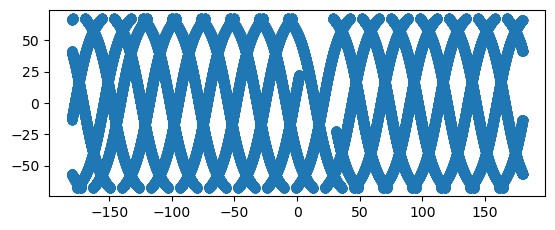

In [115]:
cpr_gdf.plot()

In [116]:
cpr_sounder_intersects = gpd.sjoin(cpr_gdf, sounder_gdf).loc[
    lambda d: (d["time"] < (d["end_time"] + pd.Timedelta("2h"))) & (d["time"] > d["start_time"])
]#.reset_index(names="index_left").sort_values(["index_left", "index_right"]).reset_index(drop=True)

In [117]:
cpr_sounder_intersects

time   latitude   longitude  \
granule along_track                                                        
01323D  1600        2024-08-22 00:05:34.032870912  53.302435 -141.522023   
        1601        2024-08-22 00:05:34.171092736  53.293660 -141.525630   
        1602        2024-08-22 00:05:34.309314816  53.284886 -141.529235   
        1603        2024-08-22 00:05:34.447536768  53.276112 -141.532841   
        1604        2024-08-22 00:05:34.585758848  53.267338 -141.536445   
...                                           ...        ...         ...   
01338H  4986        2024-08-23 00:08:19.563961984 -22.411928   31.251183   
        4987        2024-08-23 00:08:19.702813952 -22.402976   31.249324   
        4988        2024-08-23 00:08:19.841665920 -22.394024   31.247465   
        4989        2024-08-23 00:08:19.980518144 -22.385073   31.245607   
        4990        2024-08-23 00:08:20.147419136 -22.374313   31.243372   

                                        geometry  index_right  \
granule along_track                                             
01323D  1600         POINT (-141.52202 53.30244)           14   
        1601         POINT (-141.52563 53.29366)           14   
        1602         POINT (-141.52924 53.28489)           14   
        1603         POINT (-141.53284 53.27611)           14   
        1604         POINT (-141.53644 53.26734)           14   
...                                          ...          ...   
01338H  4986          POINT (31.25118 -22.41193)          258   
        4987          POINT (31.24932 -22.40298)          258   
        4988          POINT (31.24747 -22.39402)          258   
        4989          POINT (31.24561 -22.38507)          258   
        4990          POINT (31.24337 -22.37431)          258   

                                                               results  \
granule along_track                                                      
01323D  1600         {'meta': {'concept-type': 'granule', 'concept-...   
        1601         {'meta': {'concept-type': 'granule', 'concept-...   
        1602         {'meta': {'concept-type': 'granule', 'concept-...   
        1603         {'meta': {'concept-type': 'granule', 'concept-...   
        1604         {'meta': {'concept-type': 'granule', 'concept-...   
...                                                                ...   
01338H  4986         {'meta': {'concept-type': 'granule', 'concept-...   
        4987         {'meta': {'concept-type': 'granule', 'concept-...   
        4988         {'meta': {'concept-type': 'granule', 'concept-...   
        4989         {'meta': {'concept-type': 'granule', 'concept-...   
        4990         {'meta': {'concept-type': 'granule', 'concept-...   

                             start_time            end_time  
granule along_track                                          
01323D  1600        2024-08-21 23:18:00 2024-08-21 23:24:00  
        1601        2024-08-21 23:18:00 2024-08-21 23:24:00  
        1602        2024-08-21 23:18:00 2024-08-21 23:24:00  
        1603        2024-08-21 23:18:00 2024-08-21 23:24:00  
        1604        2024-08-21 23:18:00 2024-08-21 23:24:00  
...                                 ...                 ...  
01338H  4986        2024-08-22 23:42:00 2024-08-22 23:48:00  
        4987        2024-08-22 23:42:00 2024-08-22 23:48:00  
        4988        2024-08-22 23:42:00 2024-08-22 23:48:00  
        4989        2024-08-22 23:42:00 2024-08-22 23:48:00  
        4990        2024-08-22 23:42:00 2024-08-22 23:48:00  

[304950 rows x 8 columns]

In [118]:
cpr_sounder_intersects["time_diff"] = cpr_sounder_intersects.time - cpr_sounder_intersects.start_time

In [119]:
cpr_sounder_intersects.time_diff.dt.total_seconds()/3600

granule  along_track
01323D   1600           0.792787
         1601           0.792825
         1602           0.792864
         1603           0.792902
         1604           0.792940
                          ...   
01338H   4986           0.438768
         4987           0.438806
         4988           0.438845
         4989           0.438883
         4990           0.438930
Name: time_diff, Length: 304950, dtype: float64

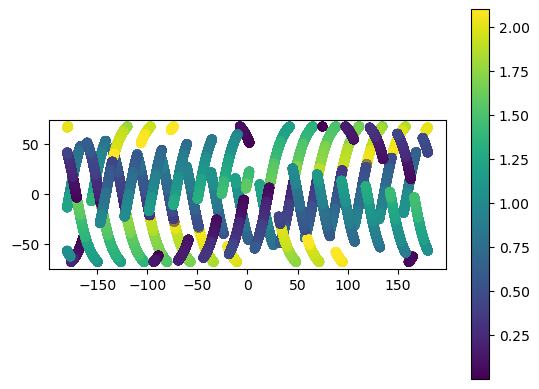

In [120]:
plot = cpr_sounder_intersects.plot(cpr_sounder_intersects.time_diff.dt.total_seconds()/3600, legend=True)

In [121]:
mean_time_diff = cpr_sounder_intersects.groupby("index_right").time_diff.mean()

<Axes: >

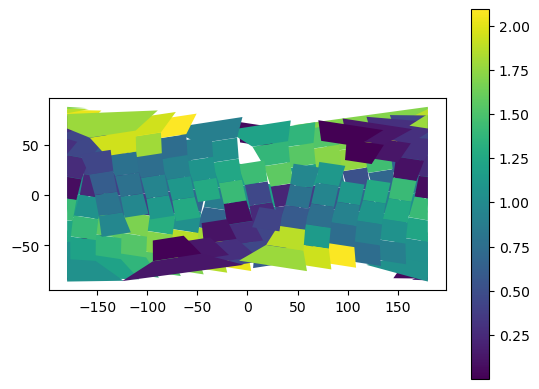

In [122]:
sounder_gdf.loc[mean_time_diff.index].plot(mean_time_diff.dt.total_seconds()/3600, legend=True)

In [123]:
earthaccess.search_datasets(
    keyword="ramses2 snpp level2"
)[1].summary()

/tmp/ipykernel_702/1487847121.py:3: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  )[1].summary()


{'short-name': 'SNDRSNML2RMS',
 'concept-id': 'C2559919298-GES_DISC',
 'version': '3',
 'file-type': '',
 'get-data': ['https://sounder.gesdisc.eosdis.nasa.gov/data/SNPP_Sounder_Level2/SNDRSNML2RMS.3/',
  'https://search.earthdata.nasa.gov/search/granules?p=C2559919298-GES_DISC'],
 'cloud-info': {'Region': 'us-west-2',
  'S3CredentialsAPIEndpoint': 'https://data.gesdisc.earthdata.nasa.gov/s3credentials',
  'S3CredentialsAPIDocumentationURL': 'https://data.gesdisc.earthdata.nasa.gov/s3credentialsREADME',
  'S3BucketAndObjectPrefixNames': ['s3://gesdisc-cumulus-prod-protected/SNPP_Sounder_Level2/SNDRSNML2RMS.3/']}}

In [124]:
results = earthaccess.search_data(
    short_name="SNDRSNML2RMS", 
    temporal=("2024-08-21 22:00:00", "2024-08-22"),
    # bounding_box=(-64, -6, -8, 24), 
    # day_night_flag="day", 
)

borders = [
    r["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]["GPolygons"][0]["Boundary"]["Points"]
    for r in results
]

sounder_polys = [
    antimeridian.fix_polygon(shapely.Polygon([list(l.values()) for l in b[:-1]]))
    for b in borders
]

sounder_dates = [
    r["umm"]["TemporalExtent"]["RangeDateTime"]
    for r in results
]

snpp_gdf = gpd.GeoDataFrame(
    data=pd.DataFrame(
        data=dict(
            results=results,
            start_time=pd.to_datetime([
                r["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"][:-1]
                for r in results
            ]), 
            end_time=pd.to_datetime([
                r["umm"]["TemporalExtent"]["RangeDateTime"]["EndingDateTime"][:-1]
                for r in results
            ]), 
        )
    ), 
    geometry=sounder_polys,
    crs="EPSG:4326"
)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [125]:
snpp_gdf

,results,start_time,end_time,geometry
0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 21:54:00,2024-08-21 22:00:00,"POLYGON ((39.94 -7.18, 33.36 -27.38, 59.3 -31...."
1,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:00:00,2024-08-21 22:06:00,"POLYGON ((33.31 -27.54, 22.28 -46.8, 57.31 -52..."
2,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:06:00,2024-08-21 22:12:00,"POLYGON ((22.18 -46.94, -1.59 -63.4, 59.36 -72..."
3,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:12:00,2024-08-21 22:18:00,"POLYGON ((180 -85.92065, 59.38 -72.94, -1.89 -..."
4,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-21 22:18:00,2024-08-21 22:24:00,"POLYGON ((-54.68 -69.16, -95.97 -57.79, -143.7..."
...,...,...,...,...
256,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:30:00,2024-08-22 23:36:00,"POLYGON ((-2.75 -51.61, -32.82 -66.48, 42.21 -..."
257,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:36:00,2024-08-22 23:42:00,"POLYGON ((180 -82.76797, 42.26 -78.16, -33.19 ..."
258,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:42:00,2024-08-22 23:48:00,"POLYGON ((-89.35 -67.49, -122.46 -53.46, -163...."
259,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-22 23:48:00,2024-08-22 23:54:00,"POLYGON ((-122.62 -53.34, -136.69 -34.71, -165..."


In [126]:
cpr_snpp_intersects = gpd.sjoin(cpr_gdf, snpp_gdf).loc[
    lambda d: (d["time"] < (d["end_time"] + pd.Timedelta("2h"))) & (d["time"] > d["start_time"])
]#.reset_index(names="index_left").sort_values(["index_left", "index_right"]).reset_index(drop=True)

In [127]:
cpr_snpp_intersects["time_diff"] = cpr_snpp_intersects.time - cpr_snpp_intersects.start_time

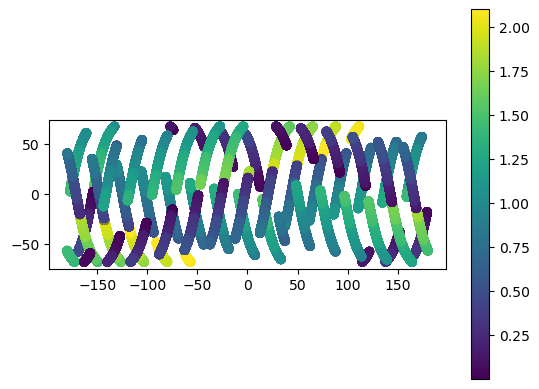

In [128]:
plot = cpr_snpp_intersects.plot(cpr_snpp_intersects.time_diff.dt.total_seconds()/3600, legend=True)

<Axes: >

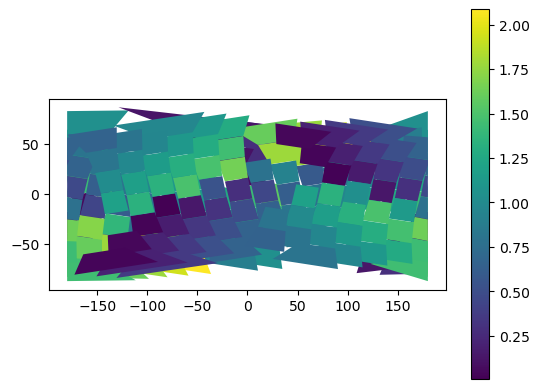

In [129]:
mean_time_diff_snpp = cpr_snpp_intersects.groupby("index_right").time_diff.mean()
snpp_gdf.loc[mean_time_diff_snpp.index].plot(mean_time_diff_snpp.dt.total_seconds()/3600, legend=True)

In [142]:
cpr_sounder_intersects.rename(dict(index_right="index_jpss1", start_time="start_time_jpss1", end_time="end_time_jpss1"), axis=1)

time   latitude   longitude  \
granule along_track                                                        
01323D  1600        2024-08-22 00:05:34.032870912  53.302435 -141.522023   
        1601        2024-08-22 00:05:34.171092736  53.293660 -141.525630   
        1602        2024-08-22 00:05:34.309314816  53.284886 -141.529235   
        1603        2024-08-22 00:05:34.447536768  53.276112 -141.532841   
        1604        2024-08-22 00:05:34.585758848  53.267338 -141.536445   
...                                           ...        ...         ...   
01338H  4986        2024-08-23 00:08:19.563961984 -22.411928   31.251183   
        4987        2024-08-23 00:08:19.702813952 -22.402976   31.249324   
        4988        2024-08-23 00:08:19.841665920 -22.394024   31.247465   
        4989        2024-08-23 00:08:19.980518144 -22.385073   31.245607   
        4990        2024-08-23 00:08:20.147419136 -22.374313   31.243372   

                                        geometry  index_jpss1  \
granule along_track                                             
01323D  1600         POINT (-141.52202 53.30244)           14   
        1601         POINT (-141.52563 53.29366)           14   
        1602         POINT (-141.52924 53.28489)           14   
        1603         POINT (-141.53284 53.27611)           14   
        1604         POINT (-141.53644 53.26734)           14   
...                                          ...          ...   
01338H  4986          POINT (31.25118 -22.41193)          258   
        4987          POINT (31.24932 -22.40298)          258   
        4988          POINT (31.24747 -22.39402)          258   
        4989          POINT (31.24561 -22.38507)          258   
        4990          POINT (31.24337 -22.37431)          258   

                                                               results  \
granule along_track                                                      
01323D  1600         {'meta': {'concept-type': 'granule', 'concept-...   
        1601         {'meta': {'concept-type': 'granule', 'concept-...   
        1602         {'meta': {'concept-type': 'granule', 'concept-...   
        1603         {'meta': {'concept-type': 'granule', 'concept-...   
        1604         {'meta': {'concept-type': 'granule', 'concept-...   
...                                                                ...   
01338H  4986         {'meta': {'concept-type': 'granule', 'concept-...   
        4987         {'meta': {'concept-type': 'granule', 'concept-...   
        4988         {'meta': {'concept-type': 'granule', 'concept-...   
        4989         {'meta': {'concept-type': 'granule', 'concept-...   
        4990         {'meta': {'concept-type': 'granule', 'concept-...   

                       start_time_jpss1      end_time_jpss1  \
granule along_track                                           
01323D  1600        2024-08-21 23:18:00 2024-08-21 23:24:00   
        1601        2024-08-21 23:18:00 2024-08-21 23:24:00   
        1602        2024-08-21 23:18:00 2024-08-21 23:24:00   
        1603        2024-08-21 23:18:00 2024-08-21 23:24:00   
        1604        2024-08-21 23:18:00 2024-08-21 23:24:00   
...                                 ...                 ...   
01338H  4986        2024-08-22 23:42:00 2024-08-22 23:48:00   
        4987        2024-08-22 23:42:00 2024-08-22 23:48:00   
        4988        2024-08-22 23:42:00 2024-08-22 23:48:00   
        4989        2024-08-22 23:42:00 2024-08-22 23:48:00   
        4990        2024-08-22 23:42:00 2024-08-22 23:48:00   

                                    time_diff  
granule along_track                            
01323D  1600        0 days 00:47:34.032870912  
        1601        0 days 00:47:34.171092736  
        1602        0 days 00:47:34.309314816  
        1603        0 days 00:47:34.447536768  
        1604        0 days 00:47:34.585758848  
...                                       ...  
01338H  4986        0 days 00:26:19.5639619

<Axes: >

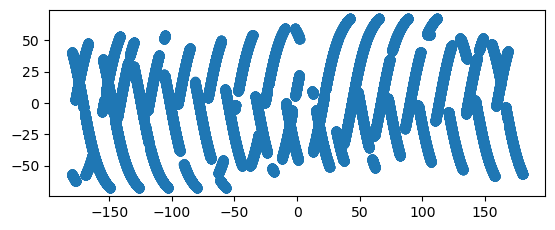

In [143]:
gpd.sjoin(cpr_sounder_intersects.rename(dict(index_right="index_jpss1", start_time="start_time_jpss1", end_time="end_time_jpss1"), axis=1), snpp_gdf).loc[
    lambda d: (d["time"] < (d["end_time"] + pd.Timedelta("2h"))) & (d["time"] > d["start_time"])
].plot()